## Model 1: Static table model (Stan)

**Idea:** fit on **historical league tables** plus **process features** from match data.  
The model outputs a **predicted end-of-season table** directly.

**Backtest:** train on tables through 2024/25 → predict table 2025/26 (`2526`).

### Technical description

For each team-season row:

$$\text{Pts} \sim t_{\nu}\big(\alpha + \beta \cdot \text{skill}_t + \gamma_1 \cdot \text{sot\_diff} + \gamma_2 \cdot \text{pts\_lag1} + \gamma_3 \cdot \text{ppg\_last10},\; \sigma_{\text{pts}}\big)$$

Student-$t$ likelihood with $\nu=5$ fixed (robust to outlier seasons; standard choice in robust regression).

| Feature | Meaning |
|---------|---------|
| `sot_diff_pg` | (shots on target for − against) per match |
| `pts_lag1` | points in previous season (0 if promoted) |
| `ppg_last10` | points per game in last 10 matchdays |

Covariates are **z-scored** on training data.  
**Forecast:** use covariates from the **last training season** (2425), sample points, **rank** → table.


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from cmdstanpy import CmdStanModel

import importlib
import helping_functions as hf
importlib.reload(hf)

from helping_functions import (
    load_matches,
    load_season_tables,
    prepare_table_stan_static,
    build_forecast_features,
    compute_table,
    predict_table,
    teams_in_season,
    STUDENT_T_NU,
    BACKTEST_TRAIN_SEASONS,
    BACKTEST_TEST_SEASON,
)


In [18]:
matches = load_matches()
TRAIN_SEASONS = BACKTEST_TRAIN_SEASONS
TEST_SEASON = BACKTEST_TEST_SEASON
FEATURE_SEASON = "2425"  # last training season → covariates for 2526 forecast

tables = load_season_tables(matches, TRAIN_SEASONS)
stan_data, team_to_idx, train_teams, feature_stats = prepare_table_stan_static(
    tables, TRAIN_SEASONS
)
stan_data["nu"] = STUDENT_T_NU  # required by table_static.stan (Student-t df)
test_teams = sorted(teams_in_season(matches, TEST_SEASON))

print(f"Training rows (team-seasons): {stan_data['N']}")
print(f"Stan keys: {sorted(stan_data.keys())}")
print(f"Teams in training: {stan_data['T']}")
print(f"Test season {TEST_SEASON}: {len(test_teams)} teams")
print(tables.groupby('season')['Pts'].mean().tail(3))
print("\nFeature ranges (raw, training seasons):")
print(tables[['sot_diff_pg', 'pts_lag1', 'ppg_last10']].describe().round(2))

new_in_test = sorted(set(test_teams) - set(train_teams))
if new_in_test:
    print("Promoted / new teams (skill=0, covariates=training mean):", new_in_test)


Training rows (team-seasons): 320
Stan keys: ['N', 'T', 'nu', 'ppg_last10', 'pts', 'pts_lag1', 'sot_diff_pg', 'team']
Teams in training: 42
Test season 2526: 20 teams
season
2223    52.65
2324    52.90
2425    52.35
Name: Pts, dtype: float64

Feature ranges (raw, training seasons):
       sot_diff_pg  pts_lag1  ppg_last10
count       320.00    320.00      320.00
mean          0.00     45.02        1.39
std           1.98     26.80        0.59
min          -4.66      0.00        0.00
25%          -1.38     38.00        0.90
50%          -0.39     47.00        1.40
75%           1.24     63.25        1.80
max           6.03    100.00        3.00


### Prior selection

| Parameter | Prior | Rationale |
|-----------|-------|-----------|
| `intercept` | $\mathcal{N}(52, 10)$ | Mean points in 20-team league (~mid-table) |
| `beta_pts` | $\mathcal{N}(20, 10)$ | Points gained per unit of latent skill |
| `beta_sot`, `beta_form` | $\mathcal{N}(0, 8)$ | Process / form effects (z-scored inputs) |
| `beta_lag` | $\mathcal{N}(0, 0.5)$ | Previous-season points (z-scored) |
| `log_sigma_pts` | $\mathcal{N}(\log 17,\, 0.3)$ | Residual scale ($\sigma=\exp(\cdot)$, stable sampling) |
| `nu` | fixed at 5 | Student-$t$ df (heavier tails than Normal) |
| `skill_raw` | $\mathcal{N}(0,1)$ | Latent team strength, centered |

**Input data:** `Pts` (target) + `sot_diff_pg`, `pts_lag1`, `ppg_last10` (predictors).


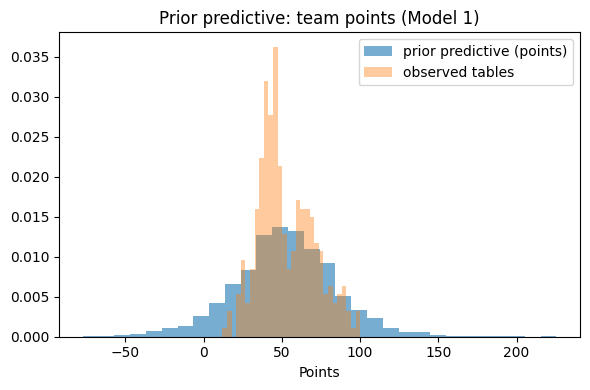

Prior mean 51.8, observed mean 52.4


In [19]:
# Prior predictive on points (bulk check)
rng = np.random.default_rng(42)
n_prior = 3000
T = stan_data["T"]
intercept_p = rng.normal(52, 10, n_prior)
beta_p = np.abs(rng.normal(20, 10, n_prior))
sigma_p = np.abs(rng.normal(17, 5, n_prior))
nu_prior = 5.0
skill_p = rng.normal(0, 1, (n_prior, T))
skill_p -= skill_p.mean(axis=1, keepdims=True)

pts_prior = []
for _ in range(2000):
    i = rng.integers(n_prior)
    t = rng.integers(T)
    mu = intercept_p[i] + beta_p[i] * skill_p[i, t]
    pts_prior.append(mu + sigma_p[i] * rng.standard_t(nu_prior))
pts_prior = np.array(pts_prior)
obs_pts = tables["Pts"].values

plt.figure(figsize=(6,4))
plt.hist(pts_prior, bins=30, density=True, alpha=0.6, label="prior predictive (points)")
plt.hist(obs_pts, bins=30, density=True, alpha=0.4, label="observed tables")
plt.xlabel("Points"); plt.legend(); plt.title("Prior predictive: team points (Model 1)")
plt.tight_layout(); plt.show()
print(f"Prior mean {pts_prior.mean():.1f}, observed mean {obs_pts.mean():.1f}")


### Fit Stan model (`stan/table_static.stan`)


In [20]:
model = CmdStanModel(stan_file="stan/table_static.stan")
fit = model.sample(
    data=stan_data,
    seed=42,
    chains=4,
    parallel_chains=4,
    iter_warmup=1000,
    iter_sampling=1000,
    adapt_delta=0.99,
    show_progress=True,
)
print(fit.diagnose())


15:39:22 - cmdstanpy - INFO - CmdStan start processing


chain 1 |          | 00:00 Status

chain 2 |          | 00:00 Status

chain 3 |          | 00:00 Status

chain 4 |          | 00:00 Status

15:39:25 - cmdstanpy - INFO - CmdStan done processing.
15:39:25 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is inf, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
	Exception: student_t_lpdf: Scale parameter is 0, but must be positive finite! (in 'table_static.stan', line 45, column 4 to column 42)
Exception: student_t_lpdf: Scale parameter is inf, but mu


Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Rank-normalized split effective sample size satisfactory for all parameters.

Rank-normalized split R-hat values satisfactory for all parameters.

Processing complete, no problems detected.



### Sampling diagnostics

Check `fit.diagnose()` for divergences, $\hat{R}$, ESS.


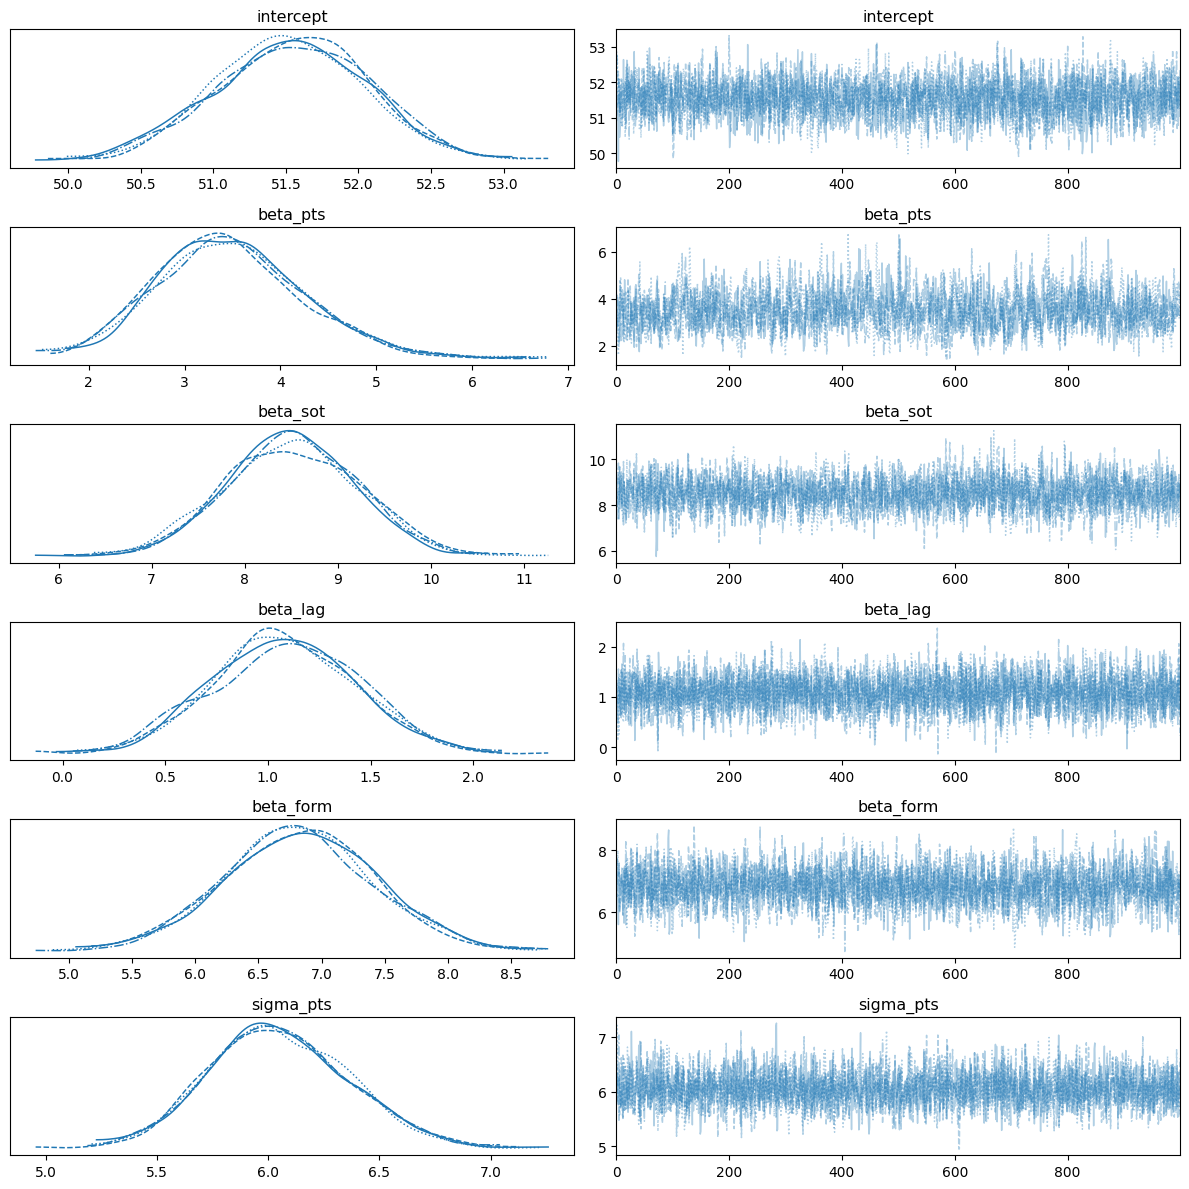

In [21]:
fit.summary().loc[
    ["intercept", "beta_pts", "beta_sot", "beta_lag", "beta_form", "sigma_pts", "lp__"]
]

idata = az.from_cmdstanpy(fit)
az.plot_trace(
    idata,
    var_names=["intercept", "beta_pts", "beta_sot", "beta_lag", "beta_form", "sigma_pts"],
    compact=True,
)
plt.tight_layout()
plt.show()


### Latent team skills (static)


In [22]:
skill_mean = fit.stan_variable("skill").mean(axis=0)
idx_to_team = {i: t for t, i in team_to_idx.items()}

strengths = pd.DataFrame({
    "team": [idx_to_team[j + 1] for j in range(len(skill_mean))],
    "skill": skill_mean,
}).sort_values("skill", ascending=False)

strengths.head(10)


,team,skill
23,Man United,1.688880
22,Man City,1.287414
2,Birmingham,1.279333
33,Stoke,1.177450
0,Arsenal,1.120662
36,Tottenham,0.902045
11,Chelsea,0.637008
4,Blackpool,0.626864
39,West Ham,0.613309
30,Reading,0.527454


### Predict table 2025/26


In [23]:
forecast_features = build_forecast_features(
    matches, FEATURE_SEASON, test_teams, TRAIN_SEASONS, feature_stats
)

pred_table = predict_table(
    fit,
    test_teams,
    team_to_idx,
    model="static",
    team_features=forecast_features,
    n_sims=500,
    seed=42,
)
pred_summary = pred_table

actual = compute_table(matches, TEST_SEASON)[["team", "position", "Pts"]]
actual = actual.rename(columns={"position": "pos_actual", "Pts": "pts_actual"})

comparison = pred_table.merge(actual, on="team", how="left")
comparison["pos_error"] = comparison["pos_median"] - comparison["pos_actual"]
comparison.sort_values("pos_actual")


,team,pos_median,pos_mean,pts_median,pts_mean,pos_actual,pts_actual,pos_error
1,Arsenal,3.0,3.648,70.428328,70.570019,1,85,2.0
0,Man City,1.0,1.794,79.401659,79.217949,2,78,-1.0
8,Man United,11.0,11.340,53.600671,53.765599,3,71,8.0
4,Aston Villa,5.0,5.540,65.517369,65.143957,4,65,1.0
2,Liverpool,4.0,4.150,68.790863,68.947129,5,60,-1.0
11,Bournemouth,13.0,12.338,51.980421,52.089249,6,57,7.0
12,Sunderland,13.0,12.450,51.622657,51.941364,7,54,6.0
7,Brighton,10.0,9.994,56.130644,56.142654,8,53,2.0
9,Brentford,12.0,12.066,52.664024,52.524189,9,53,3.0
3,Chelsea,4.0,4.450,68.380504,68.127187,10,52,-6.0


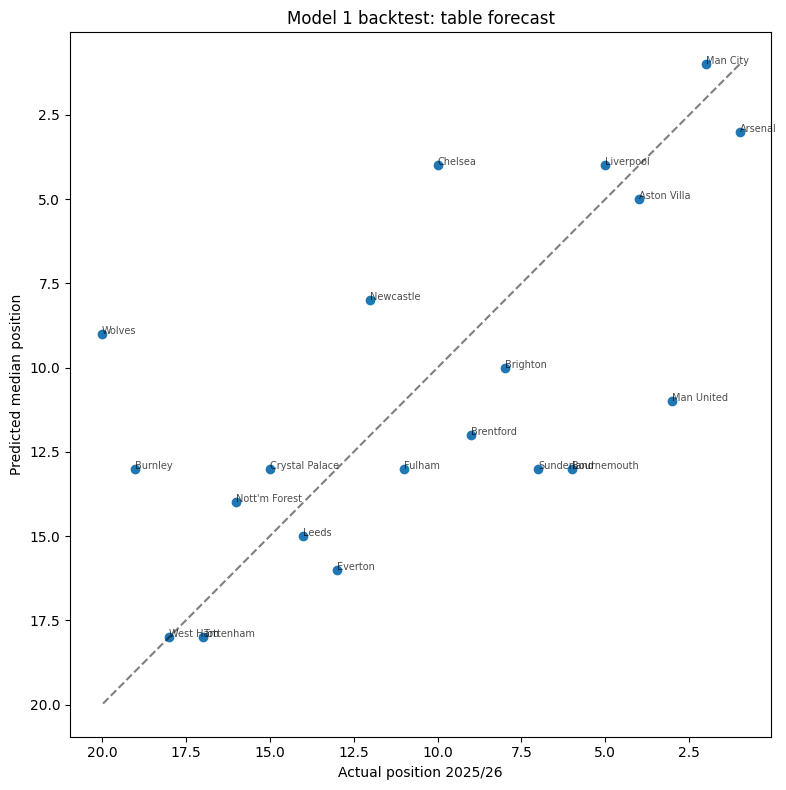

Mean absolute position error: 3.45


In [24]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(comparison["pos_actual"], comparison["pos_median"])
for _, r in comparison.iterrows():
    ax.annotate(r["team"], (r["pos_actual"], r["pos_median"]), fontsize=7, alpha=0.7)
ax.plot([1, 20], [1, 20], "k--", alpha=0.5)
ax.set_xlabel("Actual position 2025/26")
ax.set_ylabel("Predicted median position")
ax.set_title("Model 1 backtest: table forecast")
ax.invert_xaxis()
ax.invert_yaxis()
plt.tight_layout()
plt.show()

mae_pos = comparison["pos_error"].abs().mean()
print(f"Mean absolute position error: {mae_pos:.2f}")


**Interpretation:** the model never simulates individual matches — it predicts **points**, then **ranks** teams into a table.
